# DCMS Tutorial — Maximum-Entropy Solvers for Directed Networks

This notebook walks through the three maximum-entropy models implemented in the `dcms` package:

| Model | Constraints | Unknowns |
|-------|-------------|----------|
| **DCM** | out-degree, in-degree | 2N log-multipliers |
| **DWCM** | out-strength, in-strength | 2N log-multipliers |
| **aDECM** | all four | 4N log-multipliers (two-step) |
| **DECM** | all four | 4N log-multipliers (one-step) |

For each model we show:
1. The physics: which probability distribution is being maximised
2. The self-consistency equations that must be solved
3. How the two solvers work (FP-GS and θ-Newton, both with Anderson(10))
4. How to call the code and interpret the results
5. Performance tips for large networks

**Prerequisites:** `torch`, `numpy`, `matplotlib`

In [1]:
import sys, os
# Make sure the package root is on the path
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 120
mpl.rcParams['font.size'] = 11

from src.utils.wng import k_s_generator_pl

print('Imports OK')

Imports OK


## Background — Maximum-Entropy Exponential Random Graphs

### The maximum-entropy principle

Given a set of observed network properties $\mathbf{C}^* = (C_1^*, \ldots, C_K^*)$ (e.g. the degree sequence), the maximum-entropy (MaxEnt) principle asks: *what is the least biased probability distribution over all directed graphs $G$ that reproduces these observations in expectation?*

The answer is always an **exponential family**:

$$
P(G | \boldsymbol{\theta}) = \frac{1}{Z(\boldsymbol{\theta})} \exp\!\left(-\sum_{k} \theta_k C_k(G)\right)
$$

where $\boldsymbol{\theta}$ are the Lagrange multipliers and $Z$ is the partition function.  The multipliers are found by solving the self-consistency equations $\langle C_k \rangle = C_k^*$.

### Directed networks and link independence

For all three models in this package, the MaxEnt distribution factorises over directed links $(i \to j)$:

$$
P(G) = \prod_{i \neq j} p_{ij}^{A_{ij}} (1 - p_{ij})^{1 - A_{ij}} \quad \text{(binary case)}
$$

This means each link exists **independently** with probability $p_{ij}$, and the $p_{ij}$ are determined by the Lagrange multipliers.


### Parametrisation

All multipliers are stored in **log-space**: $\theta_i = -\log(x_i)$, i.e. $x_i = e^{-\theta_i}$.
Working in $\theta$-space guarantees positivity of $x_i$ without box constraints and gives a better-conditioned optimisation landscape.

## The DCM — Directed Configuration Model

### Equations

The DCM enforces the **out-degree** $k^{\text{out}}_i$ and **in-degree** $k^{\text{in}}_i$ of every node.  The link probability is:

$$
p_{ij} = \frac{x_i y_j}{1 + x_i y_j}, \qquad x_i = e^{-\theta^{\text{out}}_i}, \quad y_j = e^{-\theta^{\text{in}}_j}
$$

and the self-consistency equations are:

$$
k^{\text{out}}_i = \sum_{j \neq i} p_{ij}, \qquad
k^{\text{in}}_i = \sum_{j \neq i} p_{ji}
$$

This is a $2N \times 2N$ nonlinear system in the unknowns $(\theta^{\text{out}}_1, \ldots, \theta^{\text{out}}_N, \theta^{\text{in}}_1, \ldots, \theta^{\text{in}}_N)$.

### Generate a test network

In [2]:
# Generate a small power-law directed network (N=50)
N = 50
k, s = k_s_generator_pl(N, rho=0.1, seed=42)
k_out = k[:N].numpy().astype(float)
k_in  = k[N:].numpy().astype(float)

In [3]:
print(f'N = {N}')
print(f'k_out: min={k_out.min():.0f}  max={k_out.max():.0f}  mean={k_out.mean():.1f}')
print(f'k_in : min={k_in.min():.0f}   max={k_in.max():.0f}  mean={k_in.mean():.1f}')

N = 50
k_out: min=1  max=17  mean=5.3
k_in : min=2   max=16  mean=5.3


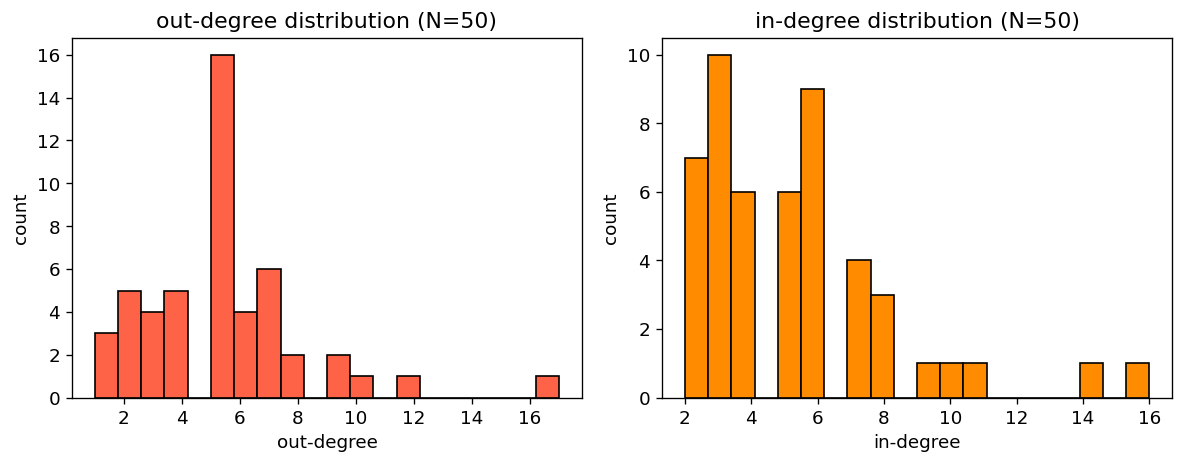

In [4]:
# Visualise the degree distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, seq, label, color in zip(axes, [k_out, k_in], ['out-degree', 'in-degree'],['tomato', 'darkorange']):
    ax.hist(seq, bins=20, color=color, edgecolor='black')
    ax.set_xlabel(label); ax.set_ylabel('count')
    ax.set_title(f'{label} distribution (N={N})')
plt.tight_layout()
plt.show()

### DCMModel

In [5]:
from src.models.dcm import DCMModel

In [6]:
model = DCMModel(k_out, k_in)

#### Solve with FP-GS Anderson(10)

In [7]:
model.solve_tool(variant='gauss-seidel', tol=1e-8)

Converged in 15 iteration(s).


True

In [8]:
print(f'FP-GS Anderson(10):')
print(f'  converged   = {model.sol.converged}')
print(f'  iterations  = {model.sol.iterations}')
print(f'  max err     = {model.constraint_error(model.sol.theta):.2e}')
print(f'  time (s)    = {model.sol.elapsed_time:.3f}')

FP-GS Anderson(10):
  converged   = True
  iterations  = 15
  max err     = 2.69e-09
  time (s)    = 0.067


In [9]:
result_fpgs_residuals=model.sol.residuals.copy()

#### Solve with θ-Newton Anderson(10)

In [10]:
model.solve_tool(variant='theta-newton', tol=1e-8)

Converged in 13 iteration(s).


True

In [11]:
print(f'θ-Newton Anderson(10):')
print(f'  converged   = {model.sol.converged}')
print(f'  iterations  = {model.sol.iterations}')
print(f'  max err     = {model.constraint_error(model.sol.theta):.2e}')
print(f'  time (s)    = {model.sol.elapsed_time:.3f}')

θ-Newton Anderson(10):
  converged   = True
  iterations  = 13
  max err     = 8.84e-09
  time (s)    = 0.033


In [12]:
result_tn_residuals=model.sol.residuals.copy()

#### Convergence curves

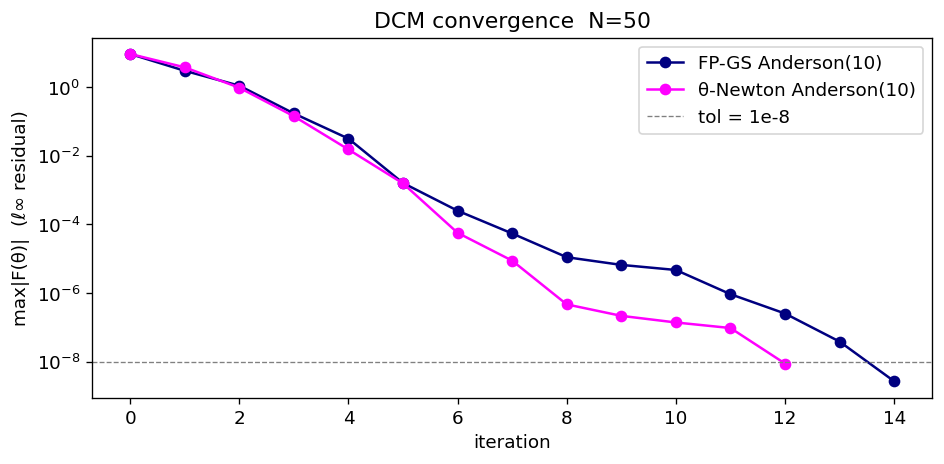

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.semilogy(result_fpgs_residuals, label='FP-GS Anderson(10)', color='navy', marker='o')
ax.semilogy(result_tn_residuals,   label='θ-Newton Anderson(10)', color='magenta', marker='o')
ax.axhline(1e-8, color='grey', linestyle='--', linewidth=0.8, label='tol = 1e-8')

ax.set_xlabel('iteration'); ax.set_ylabel('max|F(θ)|  (ℓ∞ residual)')
ax.set_title(f'DCM convergence  N={N}')
ax.legend()
plt.tight_layout()
plt.show()

#### Inspect the solution

The recovered multipliers should reproduce the observed degrees.

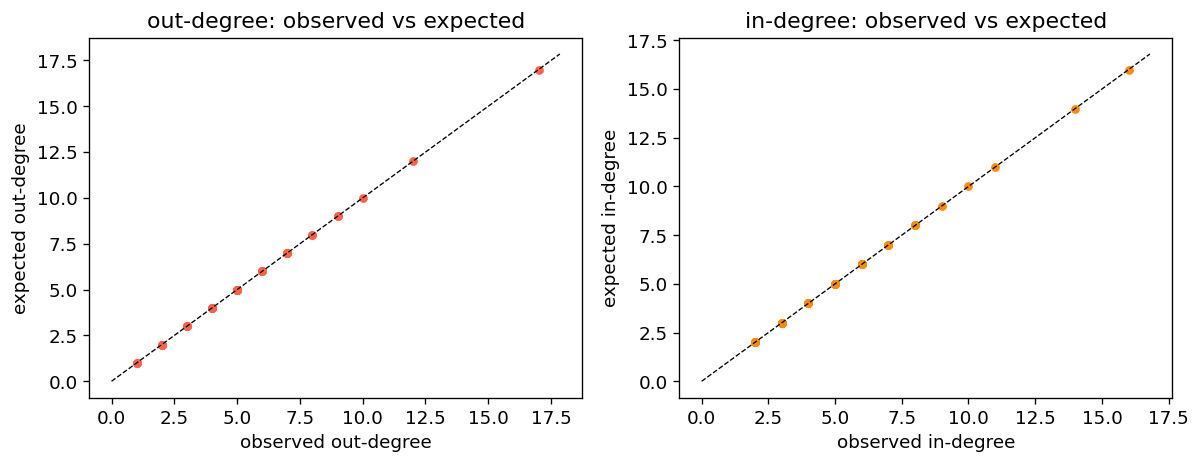

Max |Δk_out| = 8.84e-09
Max |Δk_in|  = 5.26e-09


In [14]:
theta_sol = model.sol.theta
x = np.exp(-theta_sol[:N])
y = np.exp(-theta_sol[N:])

# Reconstruct expected degrees from the solution
xy = x[:, None] * y[None, :]
P = xy / (1 + xy)
np.fill_diagonal(P, 0.0)

k_out_hat = P.sum(axis=1)
k_in_hat  = P.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, obs, rec, label, color in zip(
    axes,
    [k_out, k_in],
    [k_out_hat, k_in_hat],
    ['out-degree', 'in-degree'],
    ['tomato', 'darkorange'],
):
    lim = max(obs.max(), rec.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8)
    ax.scatter(obs, rec, s=18, color=color)
    ax.set_xlabel(f'observed {label}'); ax.set_ylabel(f'expected {label}')
    ax.set_title(f'{label}: observed vs expected')

plt.tight_layout()
plt.show()

print(f'Max |Δk_out| = {np.abs(k_out - k_out_hat).max():.2e}')
print(f'Max |Δk_in|  = {np.abs(k_in  - k_in_hat ).max():.2e}')

## The DWCM — Directed Weighted Configuration Model

### Equations

The DWCM enforces **out-strength** $s^{\text{out}}_i$ and **in-strength** $s^{\text{in}}_i$.  Weights are geometrically distributed (integer-valued), giving:

$$
\langle w_{ij} \rangle = \frac{\beta_i \beta_j}{1 - \beta_i \beta_j}, \qquad \beta_i = e^{-\theta^{\text{out}}_i}, \quad \beta_j = e^{-\theta^{\text{in}}_j}
$$

The self-consistency equations are:

$$
s^{\text{out}}_i = \sum_{j \neq i} \frac{\beta^{\text{out}}_i \beta^{\text{in}}_j}{1 - \beta^{\text{out}}_i \beta^{\text{in}}_j},
\qquad
s^{\text{in}}_i = \sum_{j \neq i} \frac{\beta^{\text{out}}_j \beta^{\text{in}}_i}{1 - \beta^{\text{out}}_j \beta^{\text{in}}_i}
$$

**Feasibility constraint:** $\beta^{\text{out}}_i \beta^{\text{in}}_j < 1$ for all $i \neq j$  (i.e. $\theta^{\text{out}}_i + \theta^{\text{in}}_j > 0$ for all pairs).

### Why is DWCM harder than DCM?

The key difference is the **geometric-distribution correction factor** $G_{ij} = 1/(1 - \beta_i \beta_j)$.  As $\beta_i \beta_j \to 1$ (high-strength hub nodes), $G_{ij} \to \infty$ and the Jacobian of the self-consistency map becomes large.  The spectral radius of the fixed-point map exceeds 1 for hub nodes, causing plain FP to diverge.

The θ-Newton approach avoids this: the diagonal Hessian element
$$
\frac{\partial F_i}{\partial \theta_i} = -\sum_{j \neq i} G_{ij}(G_{ij} - 1)
$$
is always negative, giving a descent direction regardless of how large $G_{ij}$ is.

### Generate a test network

In [15]:
# Use the strength sequences from the same network
s_out = s[:N].numpy().astype(float)
s_in  = s[N:].numpy().astype(float)

# Zero-out nodes with zero strength (not meaningful)
mask_out = s_out > 0
mask_in  = s_in  > 0
print(f'Nodes with s_out > 0: {mask_out.sum()} / {N}')
print(f'Nodes with s_in  > 0: {mask_in.sum()}  / {N}')
print(f's_out: min={s_out[mask_out].min():.0f}  max={s_out.max():.0f}  mean={s_out[mask_out].mean():.1f}')

Nodes with s_out > 0: 50 / 50
Nodes with s_in  > 0: 50  / 50
s_out: min=2  max=41  mean=12.2


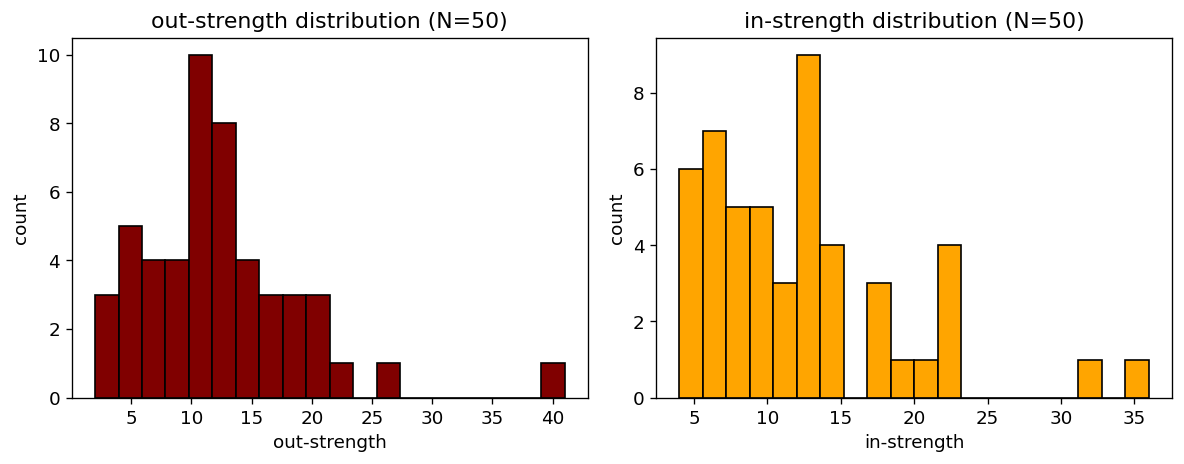

In [16]:
# Visualise the degree distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, seq, label, color in zip(axes, [s_out, s_in], ['out-strength', 'in-strength'], ['maroon', 'orange']):
    ax.hist(seq, bins=20, color=color, edgecolor='black')
    ax.set_xlabel(label); ax.set_ylabel('count')
    ax.set_title(f'{label} distribution (N={N})')
plt.tight_layout()
plt.show()

### DCWMModel

In [17]:
from src.models.dwcm import DWCMModel

In [18]:
model_w = DWCMModel(s_out, s_in)

#### Solve with FP-GS Anderson(10)

In [19]:
model_w.solve_tool(tol=1e-8, variant='gauss-seidel')

Converged in 20 iteration(s).


True

In [20]:
print(f'FP-GS Anderson(10):')
print(f'  converged   = {model_w.sol.converged}')
print(f'  iterations  = {model_w.sol.iterations}')
print(f'  max err     = {model_w.constraint_error(model_w.sol.theta):.2e}')
print(f'  time (s)    = {model_w.sol.elapsed_time:.3f}')

FP-GS Anderson(10):
  converged   = True
  iterations  = 20
  max err     = 5.57e-10
  time (s)    = 0.051


In [21]:
result_fpgs_residuals=model_w.sol.residuals.copy()

#### Solve with θ-Newton Anderson(10)

In [22]:
model_w.solve_tool(tol=1e-8, variant='theta-newton')

Converged in 14 iteration(s).


True

In [23]:
print(f'θ-Newton Anderson(10):')
print(f'  converged   = {model_w.sol.converged}')
print(f'  iterations  = {model_w.sol.iterations}')
print(f'  max err     = {model_w.constraint_error(model_w.sol.theta):.2e}')
print(f'  time (s)    = {model_w.sol.elapsed_time:.3f}')

θ-Newton Anderson(10):
  converged   = True
  iterations  = 14
  max err     = 1.47e-09
  time (s)    = 0.031


In [24]:
result_tn_residuals=model_w.sol.residuals.copy()

#### Convergence curves

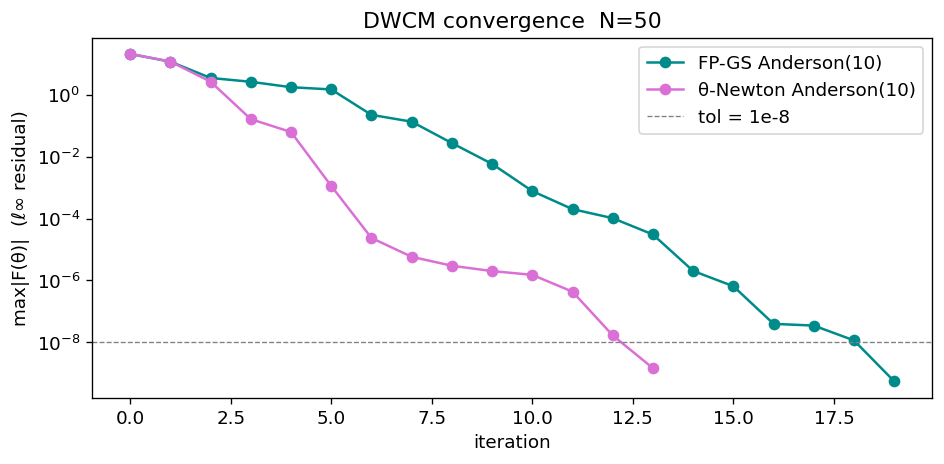

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.semilogy(result_fpgs_residuals, label='FP-GS Anderson(10)', color='darkcyan', marker='o')
ax.semilogy(result_tn_residuals,   label='θ-Newton Anderson(10)', color='orchid', marker='o')
ax.axhline(1e-8, color='grey', linestyle='--', linewidth=0.8, label='tol = 1e-8')

ax.set_xlabel('iteration'); ax.set_ylabel('max|F(θ)|  (ℓ∞ residual)')
ax.set_title(f'DWCM convergence  N={N}')
ax.legend()
plt.tight_layout()
plt.show()

#### Inspect the solution

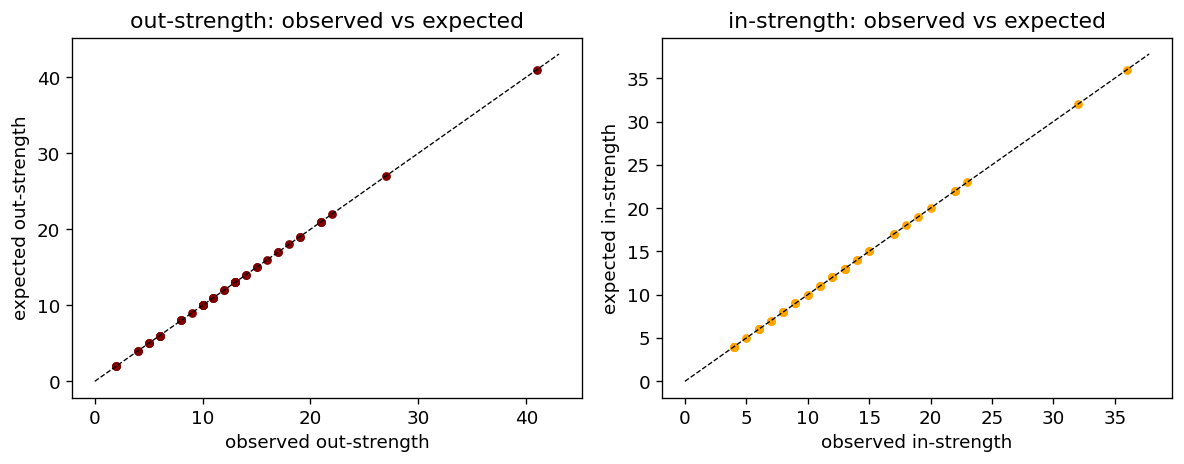

Max |Δs_out| = 1.47e-09
Max |Δs_in|  = 2.39e-10


In [26]:
theta_sol = model_w.sol.theta
x = np.exp(-theta_sol[:N])
y = np.exp(-theta_sol[N:])

# Reconstruct expected degrees from the solution
xy = x[:, None] * y[None, :]
P = xy / (1 - xy)
np.fill_diagonal(P, 0.0)

s_out_hat = P.sum(axis=1)
s_in_hat  = P.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, obs, rec, label, color in zip(
    axes,
    [s_out, s_in],
    [s_out_hat, s_in_hat],
    ['out-strength', 'in-strength'],
    ['maroon', 'orange'],
):
    lim = max(obs.max(), rec.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8)
    ax.scatter(obs, rec, s=18, color=color)
    ax.set_xlabel(f'observed {label}'); ax.set_ylabel(f'expected {label}')
    ax.set_title(f'{label}: observed vs expected')

plt.tight_layout()
plt.show()

print(f'Max |Δs_out| = {np.abs(s_out - s_out_hat).max():.2e}')
print(f'Max |Δs_in|  = {np.abs(s_in  - s_in_hat ).max():.2e}')

## The aDECM — Approximated Directed Enhanced Configuration Model

### Equations

The aDECM constrains **all four sequences**: $(k^{\text{out}}, k^{\text{in}}, s^{\text{out}}, s^{\text{in}})$.  It is solved in **two sequential steps**:

**Step 1 — Topology (DCM):** find $2N$ multipliers $(x_i, y_i)$ reproducing the degree sequences.  Result: link probabilities $p_{ij} = x_i y_j / (1 + x_i y_j)$.

**Step 2 — Weights (conditioned DWCM):** find $2N$ weight multipliers $(\beta^{\text{out}}_i, \beta^{\text{in}}_i)$ reproducing the strength sequences given the topology:

$$
s^{\text{out}}_i = \sum_{j \neq i} \frac{p_{ij}}{1 - \beta^{\text{out}}_i \beta^{\text{in}}_j},
\qquad
s^{\text{in}}_i = \sum_{j \neq i} \frac{p_{ji}}{1 - \beta^{\text{out}}_j \beta^{\text{in}}_i}
$$

> **Note on the formula:** $p_{ij}$ appears in the numerator instead of $\beta^{\text{out}}_i \beta^{\text{in}}_j$.  This is because the expected weight conditioned on the topology is $\langle w_{ij} | A_{ij}=1 \rangle = 1/(1 - \beta^{\text{out}}_i \beta^{\text{in}}_j)$, and we multiply by the link probability $p_{ij}$ to get the unconditional expectation.  The $\beta$-dependent numerator appears only in the unconditioned DWCM.

### Why is aDECM harder than DWCM?

In the DWCM, $p_{ij} = 1$ for all pairs (the model is fully weighted with no topology).  In aDECM, $p_{ij} < 1$ — it can be very small for sparse networks.  The fixed-point update for each $\beta^{\text{out}}_i$ is:

$$
\beta^{\text{out}}_i{}^{\text{new}} = \frac{s^{\text{out}}_i}{D^{\text{out}}_i}, \qquad
D^{\text{out}}_i = \frac{1}{\beta^{\text{out}}_i} \sum_{j \neq i} \frac{p_{ij}}{(1 - \beta^{\text{out}}_i \beta^{\text{in}}_j)^2}
$$

When $p_{ij}$ is small, $D^{\text{out}}_i$ is small, and $\beta^{\text{out}}_i{}^{\text{new}} = s^{\text{out}}_i / D^{\text{out}}_i$ is large.  If it exceeds $1/(\text{any } \beta^{\text{in}}_j)$, the model becomes infeasible.  This amplification effect means the fixed-point spectral radius is systematically larger in aDECM than in DWCM, which is why FP-GS Anderson(10) fails at N=5000 for aDECM but not DWCM.

The θ-Newton approach sidesteps this: by working in $\theta$-space and capping each step at `max_step` log-units, it can handle the amplification gracefully.

### ADECMModel

In [27]:
from src.models.adecm import ADECMModel

In [28]:
# Build the model with all four sequences
model_da = ADECMModel(k_out, k_in, s_out, s_in)

print('aDECM model summary:')
print(f'  N = {model_da.N}')
print(f'  Nodes with k_out > 0: {(model_da.k_out > 0).sum()}')
print(f'  Nodes with s_out > 0: {(model_da.s_out > 0).sum()}')

aDECM model summary:
  N = 50
  Nodes with k_out > 0: 50
  Nodes with s_out > 0: 50


#### Solve with FP-GS Anderson(10)

In [29]:
model_da.solve_tool(tol=1e-8, variant='gauss-seidel')

Topology: Converged in 15 iteration(s).
Weights: Converged in 32 iteration(s).


True

In [30]:
print(f'FP-GS Anderson(10):  topology')
print(f'  converged={model_da.sol_topo.converged}')
print(f'  iterations  = {model_da.sol_topo.iterations}')
print(f'  max err     = {model_da.constraint_error_topology(model_da.sol_topo.theta):.2e}')
print(f'  time (s)    = {model_da.sol_topo.elapsed_time:.3f}')

print(f'FP-GS Anderson(10):  weights')
print(f'  converged={model_da.sol_weights.converged}')
print(f'  iterations  = {model_da.sol_weights.iterations}')
print(f'  max err     = {model_da.constraint_error_strength(model_da.sol_topo.theta, model_da.sol_weights.theta):.2e}')
print(f'  time (s)    = {model_da.sol_weights.elapsed_time:.3f}')

FP-GS Anderson(10):  topology
  converged=True
  iterations  = 15
  max err     = 2.69e-09
  time (s)    = 0.027
FP-GS Anderson(10):  weights
  converged=True
  iterations  = 32
  max err     = 3.33e-11
  time (s)    = 0.054


In [31]:
result_fpgs_residuals_t=model_da.sol_topo.residuals.copy()
result_fpgs_residuals_w=model_da.sol_weights.residuals.copy()

#### Solve with θ-Newton Anderson(10)

In [32]:
model_da.solve_tool(tol=1e-8, variant='theta-newton')

Topology: Converged in 13 iteration(s).
Weights: Converged in 15 iteration(s).


True

In [33]:
print(f'θ-Newton Anderson(10):  topology')
print(f'  converged={model_da.sol_topo.converged}')
print(f'  iterations  = {model_da.sol_topo.iterations}')
print(f'  max err     = {model_da.constraint_error_topology(model_da.sol_topo.theta):.2e}')
print(f'  time (s)    = {model_da.sol_topo.elapsed_time:.3f}')

print(f'θ-Newton Anderson(10):  weights')
print(f'  converged={model_da.sol_weights.converged}')
print(f'  iterations  = {model_da.sol_weights.iterations}')
print(f'  max err     = {model_da.constraint_error_strength(model_da.sol_topo.theta, model_da.sol_weights.theta):.2e}')
print(f'  time (s)    = {model_da.sol_weights.elapsed_time:.3f}')

θ-Newton Anderson(10):  topology
  converged=True
  iterations  = 13
  max err     = 8.84e-09
  time (s)    = 0.023
θ-Newton Anderson(10):  weights
  converged=True
  iterations  = 15
  max err     = 3.30e-09
  time (s)    = 0.026


In [34]:
result_tn_residuals_t=model_da.sol_topo.residuals.copy()
result_tn_residuals_w=model_da.sol_weights.residuals.copy()

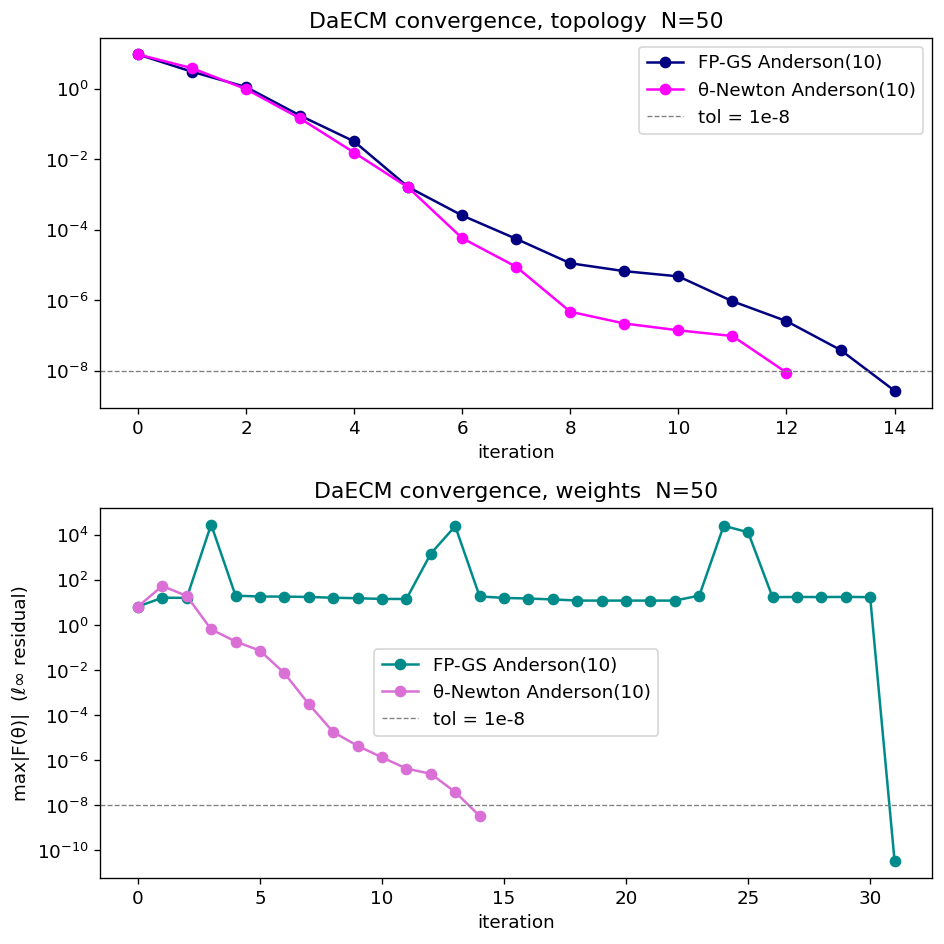

In [35]:
fig, ax = plt.subplots(nrows=2, figsize=(8, 8))

ax[0].semilogy(result_fpgs_residuals_t, label='FP-GS Anderson(10)', color='navy', marker='o')
ax[0].semilogy(result_tn_residuals_t,   label='θ-Newton Anderson(10)', color='magenta', marker='o')
ax[0].axhline(1e-8, color='grey', linestyle='--', linewidth=0.8, label='tol = 1e-8')

ax[0].set_xlabel('iteration'); ax[1].set_ylabel('max|F(θ)|  (ℓ∞ residual)')
ax[0].set_title(f'aDECM convergence, topology  N={N}')
ax[0].legend()

ax[1].semilogy(result_fpgs_residuals_w, label='FP-GS Anderson(10)', color='darkcyan', marker='o')
ax[1].semilogy(result_tn_residuals_w,   label='θ-Newton Anderson(10)', color='orchid', marker='o')
ax[1].axhline(1e-8, color='grey', linestyle='--', linewidth=0.8, label='tol = 1e-8')

ax[1].set_xlabel('iteration'); ax[1].set_ylabel('max|F(θ)|  (ℓ∞ residual)')
ax[1].set_title(f'aDECM convergence, weights  N={N}')
ax[1].legend()
plt.tight_layout()
plt.show()

## The DECM — Directed Enhanced Configuration Model

### Equations

The DECM is the **exact** maximum-entropy model that simultaneously constrains all four sequences $(k^{\text{out}}, k^{\text{in}}, s^{\text{out}}, s^{\text{in}})$ using **4N** Lagrange multipliers $(\theta^{\text{out}}_i, \theta^{\text{in}}_i, \eta^{\text{out}}_i, \eta^{\text{in}}_i)$.

Unlike the aDECM where topology and weights are decoupled, in the DECM the weight multipliers $\eta$ enter directly into the **connection probability**:

$$
p_{ij} = \sigma\!\left(-\theta^{\text{out}}_i - \theta^{\text{in}}_j + \ln\frac{1}{e^{\eta^{\text{out}}_i+\eta^{\text{in}}_j}-1}\right)
$$

The four constraint equations are:

$$
k^{\text{out}}_i = \sum_{j \neq i} p_{ij}, \qquad
k^{\text{in}}_i = \sum_{j \neq i} p_{ji}
$$
$$
s^{\text{out}}_i = \sum_{j \neq i} \frac{p_{ij}}{1 - \beta^{\text{out}}_i \beta^{\text{in}}_j}, \qquad
s^{\text{in}}_i  = \sum_{j \neq i} \frac{p_{ji}}{1 - \beta^{\text{out}}_j \beta^{\text{in}}_i}
$$

where $\beta^{\text{out}}_i = e^{-\eta^{\text{out}}_i}$.  All four equations are **coupled**: changing any $\eta$ changes $p_{ij}$, which in turn changes the degree sums.

### Why is DECM harder than aDECM?

In the aDECM, the topology step (DCM) and the weight step (conditioned DWCM) are independent: $p_{ij}$ is fixed before solving for $\beta$.  In the DECM, every change to $\eta$ modifies $p_{ij}$, so the 4N equations form a single coupled system.

The solver strategy is **alternating GS-Newton**:
1. Hold $(\eta^{\text{out}}, \eta^{\text{in}})$ fixed; update $(\theta^{\text{out}}, \theta^{\text{in}})$ with one Newton pass.
2. Hold $(\theta^{\text{out}}, \theta^{\text{in}})$ fixed; update $(\eta^{\text{out}}, \eta^{\text{in}})$ with one Newton pass.
3. Apply Anderson(10) on the full 4N vector.

For networks with high s/k hubs (strength-to-degree ratio ≫ 1), the "degrees" initial condition places the solver in a basin where the coupling term saturates $p_{ij} \to 1$ for all pairs, making the degree Hessian near-zero.  `solve_tool()` handles this automatically via **multi-start**: if the primary IC fails it retries with a aDECM warm-start (solve the approximate model first, use its 4N solution as the starting point).

### DECMModel

In [36]:
from src.models.decm import DECMModel

In [37]:
# Build the model with all four sequences
model_de = DECMModel(k_out, k_in, s_out, s_in)

print('DECM model summary:')
print(f'  N = {model_de.N}')
print(f'  Nodes with k_out > 0: {(model_de.k_out > 0).sum()}')
print(f'  Nodes with s_out > 0: {(model_de.s_out > 0).sum()}')

DECM model summary:
  N = 50
  Nodes with k_out > 0: 50
  Nodes with s_out > 0: 50


#### Solve with θ-Newton Anderson(10) (alternating GS-Newton)

In [38]:
model_de.solve_tool(tol=1e-8)

Converged in 40 iteration(s).


True

In [39]:
print(f'θ-Newton Anderson(10) [alternating GS-Newton]:')
print(f'  converged   = {model_de.sol.converged}')
print(f'  iterations  = {model_de.sol.iterations}')
print(f'  max err     = {model_de.constraint_error(model_de.sol.theta):.2e}')
print(f'  time (s)    = {model_de.sol.elapsed_time:.3f}')

θ-Newton Anderson(10) [alternating GS-Newton]:
  converged   = True
  iterations  = 40
  max err     = 9.50e-09
  time (s)    = 0.105


In [40]:
result_decm_residuals = model_de.sol.residuals.copy()

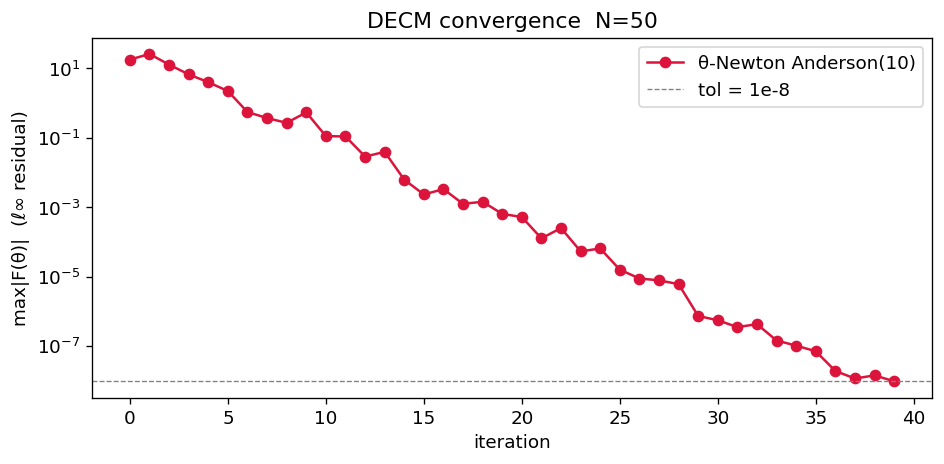

In [41]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(result_decm_residuals, label='θ-Newton Anderson(10)', color='crimson', marker='o')
ax.axhline(1e-8, color='grey', linestyle='--', linewidth=0.8, label='tol = 1e-8')
ax.set_xlabel('iteration')
ax.set_ylabel('max|F(θ)|  (ℓ∞ residual)')
ax.set_title(f'DECM convergence  N={N}')
ax.legend()
plt.tight_layout()
plt.show()

### Topology: aDECM vs. DECM

In [59]:
p_ij_vec_adecm=model_da.pij_matrix(model_da.sol_topo.theta).flatten()

## Sampling Synthetic Networks

Every model exposes a `sample(seed, chunk_size)` method that draws one independent realisation from the fitted MaxEnt distribution.  This is useful for:

- **Null-model hypothesis testing** — compare observed network properties against an ensemble of randomised networks that share the same degree/strength sequences
- **Ensemble averages** — estimate quantities that cannot be computed analytically from the fitted parameters alone
- **Validation** — verify that the fitted parameters reproduce the correct statistics on average

The output is always a list of edges, but the format depends on the model:

| Model | Output | Sampling rule |
|-------|--------|---------------|
| `DCMModel` | `[[i, j], ...]` | `A_ij ~ Bernoulli(p_ij)` |
| `DWCMModel` | `[[i, j, w], ...]` | `w_ij ~ Geom(1−β_ij)−1` (starts at 0) |
| `ADECMModel` | `[[i, j, w], ...]` | topology first, then `w ~ Geom(1−β_ij)` (starts at 1) |
| `DECMModel` | `[[i, j, w], ...]` | same, but `p_ij` uses the coupled DECM formula |

### DCM — sampling binary networks

In [ ]:
# Draw 5 realisations from the fitted DCM and compare mean degree to the observed one
import numpy as np

n_samples = 200
k_out_acc = np.zeros(N)
k_in_acc  = np.zeros(N)

for seed in range(n_samples):
    for i, j in model.sample(seed=seed):
        k_out_acc[i] += 1
        k_in_acc[j]  += 1

k_out_mean = k_out_acc / n_samples
k_in_mean  = k_in_acc  / n_samples

print(f'Max |<k_out> - k_out_obs| = {np.abs(k_out_mean - k_out).max():.3f}')
print(f'Max |<k_in>  - k_in_obs|  = {np.abs(k_in_mean  - k_in).max():.3f}')

In [ ]:
# Scatter plot: sampled mean degree vs observed degree
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, obs, mean, label in [
    (axes[0], k_out, k_out_mean, 'out-degree'),
    (axes[1], k_in,  k_in_mean,  'in-degree'),
]:
    lim = max(obs.max(), mean.max()) * 1.05
    ax.scatter(obs, mean, s=20, alpha=0.7)
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='y = x')
    ax.set_xlabel(f'observed {label}')
    ax.set_ylabel(f'sampled mean {label}')
    ax.set_title(f'DCM {label}  (N={N}, {n_samples} samples)')
    ax.legend()

plt.tight_layout()
plt.show()

### DWCM — sampling weighted networks

In [ ]:
# Compare sampled mean strength to observed strength
n_samples = 200
s_out_acc = np.zeros(N)
s_in_acc  = np.zeros(N)

for seed in range(n_samples):
    for i, j, w in model_w.sample(seed=seed):
        s_out_acc[i] += w
        s_in_acc[j]  += w

s_out_mean = s_out_acc / n_samples
s_in_mean  = s_in_acc  / n_samples

print(f'Max |<s_out> - s_out_obs| / s_out_obs = {(np.abs(s_out_mean - s_out) / np.maximum(s_out, 1)).max():.3f}')
print(f'Max |<s_in>  - s_in_obs|  / s_in_obs  = {(np.abs(s_in_mean  - s_in)  / np.maximum(s_in,  1)).max():.3f}')

In [ ]:
# Show the weight distribution of a single sample
sample_w = model_w.sample(seed=0)
weights = [w for _, _, w in sample_w]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(weights, bins=range(1, max(weights) + 2), align='left', color='darkcyan', edgecolor='white')
ax.set_xlabel('weight')
ax.set_ylabel('count')
ax.set_title(f'DWCM weight distribution — one sample  (N={N})')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### aDECM and DECM — sampling binary + weighted networks

In [ ]:
# Single sample from aDECM and DECM; compare the two
sample_da = model_da.sample(seed=42)
sample_de = model_de.sample(seed=42)

print(f'aDECM: {len(sample_da)} edges,  mean weight = {np.mean([w for *_, w in sample_da]):.2f}')
print(f'DECM:  {len(sample_de)} edges,  mean weight = {np.mean([w for *_, w in sample_de]):.2f}')

In [ ]:
# Verify: sampled mean degree and strength vs observed (aDECM)
n_samples = 100
k_out_da = np.zeros(N); k_in_da = np.zeros(N)
s_out_da = np.zeros(N); s_in_da = np.zeros(N)

for seed in range(n_samples):
    for i, j, w in model_da.sample(seed=seed):
        k_out_da[i] += 1;  k_in_da[j] += 1
        s_out_da[i] += w;  s_in_da[j] += w

k_out_da /= n_samples; k_in_da /= n_samples
s_out_da /= n_samples; s_in_da /= n_samples

print('aDECM sampled means vs observed:')
print(f'  Max degree err (out): {np.abs(k_out_da - k_out).max():.3f}')
print(f'  Max degree err (in):  {np.abs(k_in_da  - k_in).max():.3f}')
nz = s_out > 0
print(f'  Max strength rel err (out): {(np.abs(s_out_da[nz] - s_out[nz]) / s_out[nz]).max():.3f}')
nz = s_in > 0
print(f'  Max strength rel err (in):  {(np.abs(s_in_da[nz]  - s_in[nz])  / s_in[nz]).max():.3f}')

In [60]:
p_ij_vec_decm=model_de.pij_matrix(model_de.sol.theta).flatten()

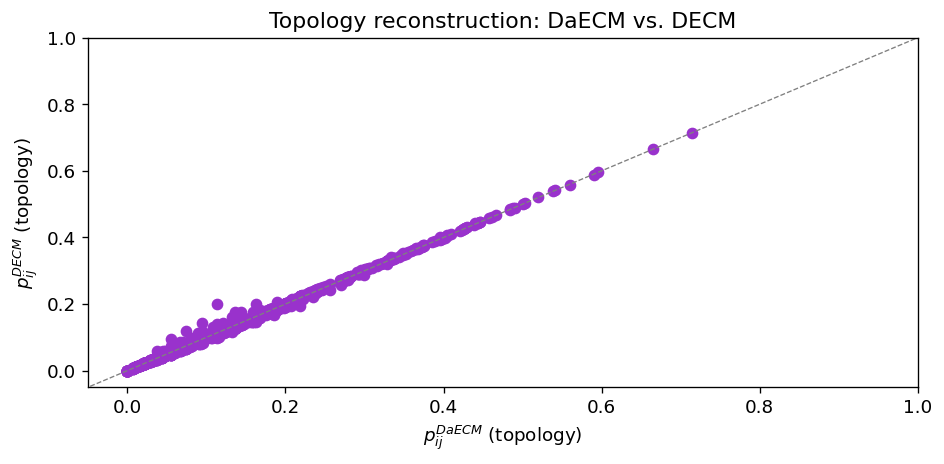

In [69]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(p_ij_vec_adecm, p_ij_vec_decm, color='darkorchid', marker='o')
ax.plot([-1, 2], [-1, 2], color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel(r'$p_{ij}^{aDECM}$ (topology)')
ax.set_ylabel('$p_{ij}^{DECM}$ (topology)')
ax.set_title(f'Topology reconstruction: aDECM vs. DECM')
ax.set_xlim(-0.05,1)
ax.set_ylim(-0.05,1)
plt.tight_layout()
plt.show()

The agreement is worse for lower probabilities, i.e. low degree nodes.

## How the Solvers Work

### FP-GS — Gauss-Seidel Fixed-Point Iteration

The self-consistency equations can be written as $\boldsymbol{\theta} = \mathbf{g}(\boldsymbol{\theta})$.  Fixed-point iteration simply iterates:

$$
\boldsymbol{\theta}^{(t+1)} = \mathbf{g}(\boldsymbol{\theta}^{(t)})
$$

For the DCM, the update for node $i$'s out-multiplier is:

$$
x_i^{\text{new}} = \frac{k^{\text{out}}_i}{\sum_{j \neq i} y_j / (1 + x_i y_j)}, \qquad
\theta^{\text{out}}_i{}^{\text{new}} = -\log(x_i^{\text{new}})
$$

**Gauss-Seidel ordering:** update all $\theta^{\text{out}}_i$ first, then use the fresh values to update all $\theta^{\text{in}}_j$.  This reduces the spectral radius of the fixed-point map compared to Jacobi (simultaneous) updates.

**Convergence condition:** FP converges when the spectral radius $\rho(\partial \mathbf{g}/\partial \boldsymbol{\theta}) < 1$.  This holds for uniform networks but may fail for hub nodes (high degree/strength).


### θ-Newton — Coordinate Newton in Log-Space

Instead of fixed-point, treat the equations as a nonlinear system $F(\boldsymbol{\theta}) = 0$ and apply a **diagonal Newton step**:

$$
\Delta\theta^{\text{out}}_i = -\frac{F^{\text{out}}_i(\boldsymbol{\theta})}{\partial F^{\text{out}}_i / \partial \theta^{\text{out}}_i}
$$

For the DCM:
$$
F^{\text{out}}_i = \hat{k}^{\text{out}}_i - k^{\text{out}}_i, \qquad
\frac{\partial F^{\text{out}}_i}{\partial \theta^{\text{out}}_i} = -\sum_{j \neq i} p_{ij}(1 - p_{ij})
$$

The step is clipped to $[-\texttt{max\_step}, +\texttt{max\_step}]$ to prevent overshooting.

**Why it works for hubs:** the denominator $\sum p(1-p)$ grows with the node's degree, naturally scaling down the step for high-degree hubs and preventing oscillation.


### Anderson Acceleration

Both methods support Anderson(m) acceleration.  Given the last $m$ iterates and their residuals:

$$
r_k = g(\boldsymbol{\theta}_k) - \boldsymbol{\theta}_k
$$

find coefficients $c_0, \ldots, c_{m-1}$ (summing to 1) that minimise $\|\sum c_k r_k\|^2$ and set:

$$
\boldsymbol{\theta}_{\text{next}} = \sum_k c_k \, g(\boldsymbol{\theta}_k)
$$

This is equivalent to a quasi-Newton method using the last $m$ secant pairs.  Typical speedup: 5–50× fewer iterations.

Running plain FP
Converged in 24 iteration(s).
Running Anderson(5)
Converged in 14 iteration(s).
Running Anderson(10)
Converged in 15 iteration(s).
Running Anderson(15)
Converged in 20 iteration(s).


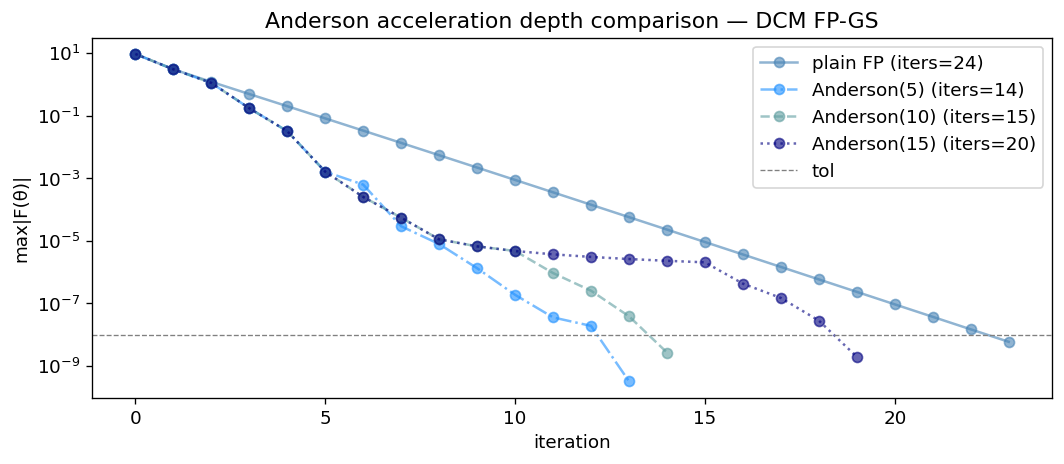

In [88]:
# Compare plain FP vs Anderson(1) vs Anderson(10) on DCM
fig, ax = plt.subplots(figsize=(9, 4))

colors = ['steelblue', 'dodgerblue','cadetblue', 'navy', 'blue', 'darkblue']
lss=['-', '-.', '--', ':', '-', '-.']
labels_depths = [('plain FP', 0), ('Anderson(5)', 5), ('Anderson(10)', 10), ('Anderson(15)', 15)]

for (label, depth), color, ls in zip(labels_depths, colors, lss):
    print(f"Running {label}")
    model.solve_tool(variant='gauss-seidel', tol=1e-8, anderson_depth=depth)
    ax.semilogy(model.sol.residuals, label=f'{label} (iters={model.sol.iterations})', color=color, linestyle=ls, marker='o', alpha=0.6)

ax.axhline(1e-8, color='gray', linestyle='--', linewidth=0.8, label='tol')
ax.set_xlabel('iteration'); ax.set_ylabel('max|F(θ)|')
ax.set_title('Anderson acceleration depth comparison — DCM FP-GS')
ax.legend()
plt.tight_layout()
plt.show()

## Parametrisation and Initial Conditions

### Why θ-space?

All multipliers are stored as $\theta_i = -\log(x_i) > 0$.  This ensures:
- $x_i = e^{-\theta_i} > 0$ without box constraints
- $z_{ij} = \theta^{\text{out}}_i + \theta^{\text{in}}_j > 0$ (feasibility for DWCM/aDECM) can be enforced as a simple linear inequality
- The likelihood surface is smoother and better conditioned in $\theta$-space

### Initial conditions matter

Good initial conditions reduce iteration counts significantly.  The models provide several options:

In [70]:
# DCM initial conditions
model.solve_tool(variant='theta-newton', ic='degrees') # θ_i = -log(k_i / (N-1))
model.solve_tool(variant='theta-newton', ic='random')   # uniform in [0.5, 2.5]

Converged in 9 iteration(s).
Converged in 10 iteration(s).


True

In [71]:
# DWCM initial conditions
model_w.solve_tool(variant='theta-newton', ic='strengths')  # θ_i = -log(s_i / (N-1))
model_w.solve_tool(variant='theta-newton', ic='normalized') # normalised version
model_w.solve_tool(variant='theta-newton', ic='random')  # uniform θ_β ∈ [0.1, 2.0].

Converged in 12 iteration(s).
Converged in 38 iteration(s).
Converged in 14 iteration(s).


True

In [72]:
# aDECM weight initial conditions
model_da.solve_tool(variant='theta-newton', ic_weights='topology') # mean-field init β = sqrt(s/(s+k))
model_da.solve_tool(variant='theta-newton', ic_weights='topology_node') #per-node Newton solve. O(N²) total; gives the most accurate starting point.

Topology: Converged in 9 iteration(s).
Weights: Converged in 12 iteration(s).
Topology: Converged in 9 iteration(s).
Weights: Converged in 10 iteration(s).


True

In [74]:
# aDECM weight initial conditions
model_de.solve_tool(ic='degrees') # θ from k/(N-1) heuristic; η from β = sqrt(1 − k/s) mean-field
model_de.solve_tool(ic='random') # Uniform random θ ∈ [0.1, 2.0], η ∈ [0.1, 2.0]

Converged in 30 iteration(s).
Converged in 56 iteration(s).


True

## Working with Large Networks

### The chunked computation path

For N > 2000, constructing the full N×N probability matrix requires O(N²) RAM (200 MB at N=5000, 20 GB at N=50000).  All solvers in this package automatically switch to a **chunked path** for N > `_LARGE_N_THRESHOLD = 2000`:

- The N×N matrix is never fully materialised
- Instead, rows are processed in blocks of `chunk_size = 512`
- Peak RAM per iteration: O(chunk × N) = O(512 × N) ≈ 20 MB at N=5000
- Same numerical result; slightly higher overhead per iteration

In [75]:
# Medium-scale example: N=500 (dense path)
N_large = 500
k_large, _ = k_s_generator_pl(N_large, rho=1e-2, seed=7)
k_out_l = k_large[:N_large].numpy().astype(float)
k_in_l  = k_large[N_large:].numpy().astype(float)

model_l = DCMModel(k_out_l, k_in_l)
model_l.solve_tool(variant='theta-newton', tol=1e-6, anderson_depth=7)

print(f'N={N_large}:  converged={model_l.sol.converged}  iters={model_l.sol.iterations}')
print(f'  max_err = {model_l.constraint_error(model_l.sol.theta):.2e}')
print(f'  time (s) = {model_l.sol.elapsed_time:.3f}')
print(f'  peak RAM = {model_l.sol.peak_ram_bytes / 1e3:.1f} kB')

Converged in 11 iteration(s).
N=500:  converged=True  iters=11
  max_err = 1.90e-07
  time (s) = 0.109
  peak RAM = 4.2 kB


### Robustness features

All three solvers include several robustness features:

| Feature | Purpose |
|---------|---------|
| **θ clamping** ($\theta \in [-50, 50]$) | Prevents numerical overflow in $exp(-\theta)$ |
| **z-floor guard** (DWCM/aDECM) | Ensures $\theta_\text{out} + \theta_\text{out} > 1e-8$ for all pairs |
| **Anderson blowup reset** | When residual jumps >5000×, clears history and reverts to `best_theta` |
| **Anderson infeasibility reject** | If Anderson mix violates z-floor, rejects and uses plain Newton step |
| **best_theta tracking** | Returns lowest-residual iterate, not final iterate |
| **Node-level Newton fallback** (FP-GS) | When $\|\Delta\theta_{\mathrm{FP}}\| > 0.1$, uses exact diagonal Newton step for that node |


### Timeout and multi-init

The `max_time` parameter (in seconds) is honoured at the iteration level.  For the comparison benchmarks, a multi-initialisation wrapper tries multiple starting points and returns the best converged result:

In [76]:
model_l.solve_tool(variant='theta-newton', ic='degrees', tol=1e-12, max_iter=100_000, max_time=0.5, anderson_depth=7)
print(f'Timed run: converged={model_l.sol.converged}  iters={model_l.sol.iterations}')
print(f'  max_err={model_l.constraint_error(model_l.sol.theta):.2e}  time={model_l.sol.elapsed_time:.3f}s')

Converged in 17 iteration(s).
Timed run: converged=True  iters=17
  max_err=4.26e-14  time=0.073s


## Interpreting the results

Every solver in `DCMMOdel`, `DWCMMOdel` and `DECMMOdel` add a `sol` attribute to the object. `sol` has the structure of the `SolverResult` dataclass:

In [77]:
from src.solvers.base import SolverResult

In [78]:
model.solve_tool(variant='theta-newton')

Converged in 9 iteration(s).


True

In [79]:
print(repr(model.sol))
print(f'Fields:')
print(f'  theta          : np.ndarray shape ({len(model.sol.theta)},) — solution in θ-space')
print(f'  converged      : {model.sol.converged}          — True if tol reached')
print(f'  iterations     : {model.sol.iterations}             — number of outer iterations')
print(f'  residuals      : list of {len(model.sol.residuals)} floats — ℓ∞ residual history')
print(f'  elapsed_time   : {model.sol.elapsed_time:.4f}       — wall-clock seconds')
print(f'  peak_ram_bytes : {model.sol.peak_ram_bytes}     — tracemalloc peak')
print(f'  message        : "{model.sol.message}"')

SolverResult(CONVERGED, iters=9, final_residual=4.692e-07, time=0.015s, peak_ram=5.1 KB)
Fields:
  theta          : np.ndarray shape (100,) — solution in θ-space
  converged      : True          — True if tol reached
  iterations     : 9             — number of outer iterations
  residuals      : list of 9 floats — ℓ∞ residual history
  elapsed_time   : 0.0152       — wall-clock seconds
  peak_ram_bytes : 5264     — tracemalloc peak
  message        : "Converged in 9 iteration(s)."


In the case of aDECM, the solver returns two different attributes, i.e. `sol_topo` and `sol_weights` that has the struucture of the `SolverResult` dataclass. `sol_topo` and `sol_weight` encode, respectively, the information for the topology and for the weights:

In [83]:
model_da.solve_tool(variant='theta-newton')

Topology: Converged in 9 iteration(s).
Weights: Converged in 12 iteration(s).


True

In [84]:
print(repr(model_da.sol_topo))
print(f'Fields:')
print(f'  theta          : np.ndarray shape ({len(model_da.sol_topo.theta)},) — solution in θ-space')
print(f'  converged      : {model_da.sol_topo.converged}          — True if tol reached')
print(f'  iterations     : {model_da.sol_topo.iterations}             — number of outer iterations')
print(f'  residuals      : list of {len(model_da.sol_topo.residuals)} floats — ℓ∞ residual history')
print(f'  elapsed_time   : {model_da.sol_topo.elapsed_time:.4f}       — wall-clock seconds')
print(f'  peak_ram_bytes : {model_da.sol_topo.peak_ram_bytes}     — tracemalloc peak')
print(f'  message        : "{model_da.sol_topo.message}"')

SolverResult(CONVERGED, iters=9, final_residual=4.692e-07, time=0.017s, peak_ram=4.1 KB)
Fields:
  theta          : np.ndarray shape (100,) — solution in θ-space
  converged      : True          — True if tol reached
  iterations     : 9             — number of outer iterations
  residuals      : list of 9 floats — ℓ∞ residual history
  elapsed_time   : 0.0166       — wall-clock seconds
  peak_ram_bytes : 4156     — tracemalloc peak
  message        : "Converged in 9 iteration(s)."


In [85]:
print(repr(model_da.sol_weights))
print(f'Fields:')
print(f'  theta          : np.ndarray shape ({len(model_da.sol_weights.theta)},) — solution in θ-space')
print(f'  converged      : {model_da.sol_weights.converged}          — True if tol reached')
print(f'  iterations     : {model_da.sol_weights.iterations}             — number of outer iterations')
print(f'  residuals      : list of {len(model_da.sol_weights.residuals)} floats — ℓ∞ residual history')
print(f'  elapsed_time   : {model_da.sol_weights.elapsed_time:.4f}       — wall-clock seconds')
print(f'  peak_ram_bytes : {model_da.sol_weights.peak_ram_bytes}     — tracemalloc peak')
print(f'  message        : "{model_da.sol_weights.message}"')

SolverResult(CONVERGED, iters=12, final_residual=4.193e-07, time=0.070s, peak_ram=5.0 KB)
Fields:
  theta          : np.ndarray shape (100,) — solution in θ-space
  converged      : True          — True if tol reached
  iterations     : 12             — number of outer iterations
  residuals      : list of 12 floats — ℓ∞ residual history
  elapsed_time   : 0.0701       — wall-clock seconds
  peak_ram_bytes : 5151     — tracemalloc peak
  message        : "Converged in 12 iteration(s)."


## Quick Reference

```python
# DCM
from src.models.dcm import DCMModel

model = DCMModel(k_out, k_in)
model.solve_tool(ic='degrees', tol=1e-6, max_iter=2000, max_time=0, variant='theta-newton', anderson_depth=10)

# DWCM
from src.models.dwcm import DWCMModel

model_w = DWCMModel(s_out, s_in)
model_w.solve_tool(ic='strengths', tol1e-6, max_iter=2000, max_time=0, variant'theta-newton', anderson_depth=10)


# aDECM (two-step)
from src.models.adecm import ADECMModel

model = ADECMModel(k_out, k_in, s_out, s_in)
model_da.solve_tool(ic_topo='degrees', ic_weights='topology', tol=1e-6, max_iter=2000, max_time=0, variant='theta-newton', anderson_depth=10)


# DECM
from src.models.decm import DECMModel

model_de = DECMModel(k_out, k_in, s_out, s_in)
model_de.solve_tool(ic="degrees", tol=1e-6, max_iter=5000, max_time=0, anderson_depth=10)

```


### Choosing the right solver

| Situation | Recommended solver |
|-----------|--------------------|
| DCM, any size | Either; both 100% convergent |
| DWCM, N ≤ 5000, typical network | FP-GS Anderson(10) (faster) |
| DWCM, N ≤ 5000, hard network (high s/k) | θ-Newton Anderson(10) (more robust) |
| DWCM, N > 5000 | θ-Newton Anderson(10) |
| aDECM, DECM, any size | θ-Newton Anderson(10) (**only reliable method at N ≥ 5000**) |

---
## References

1. Park, J. & Newman, M.E.J. (2004). Statistical mechanics of networks. *Physical Review E*, **70**, 066117.

2. Squartini, T. & Garlaschelli, D. (2011). Analytical maximum-likelihood method to detect patterns in real networks. *New Journal of Physics*, 13, 083001. https://doi.org/10.1088/1367-2630/13/8/083001

3. Mastrandrea, R., Squartini, T., Fagiolo G., and Garlaschelli, D. (2014). Enhanced reconstruction of weighted networks from strengths and degrees. *New Journal of Physics*, 16 043022
https://iopscience.iop.org/article/10.1088/1367-2630/16/4/043022

4. Gabrielli, A, Mastrandrea, R., Caldarelli, G. and Cimini, G. (2019) Grand canonical ensemble of weighted networks. *Phys. Rev. E* 99, 030301(R) 
https://journals.aps.org/pre/abstract/10.1103/PhysRevE.99.030301

5. Parisi, F., Squartini, T. and Garlaschelli, D. (2020). A faster horse on a safer trail: generalized inference for the efficient reconstruction of weighted networks. *New Journal of Physics*, 22 053053
https://iopscience.iop.org/article/10.1088/1367-2630/ab74a7

6. Walker, H.F. & Ni, P. (2011). Anderson acceleration for fixed-point iterations. *SIAM Journal on Numerical Analysis*, **49**(4), 1715–1735.